<a href="https://colab.research.google.com/github/INmais/PyPSA-Eur/blob/main/PyPSA_Eur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [42]:
! apt-get install -y graphviz libgraphviz-dev #data viz
! pip install pygraphviz diagrams # diagrams
! pip install pandapower["all"] #data
! pip install scipy #transform .m to .pp
! pip install pydot graphviz # for HG
! pip install plotly #cute plots
! pip install netowrkx #cute plots
! pip install -U kaleido #to save png IO
! pip install geopandas
! pip install contextily
! pip install shapely
! pip install fiona
! pip install contextily
! pip install pypsa
! pip install pypsa[plot] cartopy

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
ERROR: Could not find a version that satisfies the requirement netowrkx (from versions: none)
ERROR: No matching distribution found for netowrkx


source: https://zenodo.org/records/14144752

In [26]:
#from google.colab import drive
#drive.mount('/content/drive')
#import os
#os.chdir("/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/PyPSA-Eur")
# files in
#!ls "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/PyPSA-Eur/14144752 (Unzipped Files)"

In [43]:
import pandas as pd

# 1. base URL

base_url = "https://raw.githubusercontent.com/INmais/PyPSA-Eur/refs/heads/main/Data/"

component_files = [
    "buses.csv",
    "lines.csv",
    "transformers.csv",
    "links.csv",
    "converters.csv"
]

print("Starting to test CSV files from GitHub...")

for file_name in component_files:
    # 2. full URL using an f-string
    file_url = f"{base_url}{file_name}"

    print(f"Attempting to read: {file_name}")

    # 3. read directly from the URL
    try:

        df = pd.read_csv(file_url, index_col=0)

        print(f"Successfully read: {file_name}")

        print(f"   -> Data Shape: {df.shape}")

    except Exception as e:
        print(f"\n!!!!!!!! ERROR !!!!!!!!")
        print(f"Failed to read file: {file_name}")
        print(f"URL Attempted: {file_url}")
        print(f"Error message: {e}")

        break

Starting to test CSV files from GitHub...
Attempting to read: buses.csv
Successfully read: buses.csv
   -> Data Shape: (6737, 9)
Attempting to read: lines.csv

!!!!!!!! ERROR !!!!!!!!
Failed to read file: lines.csv
URL Attempted: https://raw.githubusercontent.com/INmais/PyPSA-Eur/refs/heads/main/Data/lines.csv
Error message: Error tokenizing data. C error: Expected 31 fields in line 3, saw 177



In [44]:
import urllib.request

file_url = "https://raw.githubusercontent.com/INmais/PyPSA-Eur/refs/heads/main/Data/lines.csv"

print(f"--- INSPECTING RAW DATA ---")
try:
    with urllib.request.urlopen(file_url) as response:

        for i in range(4):
            line = response.readline().decode('utf-8').strip()
            print(f"Line {i+1}: {line}")
            print("-" * 50)
except Exception as e:
    print(f"Error: {e}")

--- INSPECTING RAW DATA ---
Line 1: line_id,bus0,bus1,voltage,i_nom,circuits,s_nom,r,x,b,length,underground,under_construction,type,tags,geometry
--------------------------------------------------
Line 2: merged_relation/10264161-225+1,way/150329778-225,way/239609000-225,225,1.29,1,502.728,0.355354,1.782691,2.326e-05,5922.56,f,f,Al/St 240/40 2-bundle 220.0,way/393286545-225;relation/10264161-225,'LINESTRING (5.972758751828162 43.15786415605207, 5.979089058045948 43.15992339751134, 5.9814071 43.1603645, 5.9861104 43.1600354, 5.9919429 43.1580462, 5.9958593 43.1569153, 6.0003582 43.1556003, 6.0056593 43.1540476, 6.0091669 43.1547101, 6.0146603 43.1557939, 6.0176531 43.1563628, 6.0242387 43.1526868, 6.0238047 43.1495861, 6.023541 43.1472547, 6.023374128955794 43.14563292121518, 6.020390336307422 43.140883886040456)'
--------------------------------------------------
Line 3: merged_relation/11762422-400-b+2,way/761507281-400,way/111162936-400,400,2.58,1,1787.476,1.777477,14.575313,0.000256

In [45]:
import pandas as pd

# 1. Define the URL
file_url = "https://raw.githubusercontent.com/INmais/PyPSA-Eur/refs/heads/main/Data/lines.csv"

print(f"Attempting to read from: {file_url}")

try:
    # 2. Read with quotechar set to single quote
    df = pd.read_csv(file_url, index_col=0, quotechar="'")

    print("Successfully read: lines.csv")
    print(f"Data Shape: {df.shape}")
    print("\nFirst 3 rows:")
    print(df.head(3))

except Exception as e:
    print(f"\n!!!!!!!! ERROR !!!!!!!!")
    print(f"Error message: {e}")

Attempting to read from: https://raw.githubusercontent.com/INmais/PyPSA-Eur/refs/heads/main/Data/lines.csv
Successfully read: lines.csv
Data Shape: (8994, 15)

First 3 rows:
                                               bus0               bus1  \
line_id                                                                  
merged_relation/10264161-225+1    way/150329778-225  way/239609000-225   
merged_relation/11762422-400-b+2  way/761507281-400  way/111162936-400   
merged_relation/1208415-380-c+1    way/23380800-380   way/24478889-380   

                                  voltage  i_nom  circuits     s_nom  \
line_id                                                                
merged_relation/10264161-225+1        225   1.29         1   502.728   
merged_relation/11762422-400-b+2      400   2.58         1  1787.476   
merged_relation/1208415-380-c+1       380   2.58         1  1698.103   

                                         r          x         b    length  \
line_id          

In [46]:
import urllib.request

file_url = "https://raw.githubusercontent.com/INmais/PyPSA-Eur/refs/heads/main/Data/lines.csv"

print(f"Reading first 5 lines from: {file_url}\n")

try:

    with urllib.request.urlopen(file_url) as response:
        for i in range(5):

            line = response.readline().decode('utf-8')
            if not line:
                break
            # .strip() removes the extra newline character for cleaner printing
            print(f"Line {i+1}: {line.strip()}")

except Exception as e:
    print(f"Error reading file: {e}")

Reading first 5 lines from: https://raw.githubusercontent.com/INmais/PyPSA-Eur/refs/heads/main/Data/lines.csv

Line 1: line_id,bus0,bus1,voltage,i_nom,circuits,s_nom,r,x,b,length,underground,under_construction,type,tags,geometry
Line 2: merged_relation/10264161-225+1,way/150329778-225,way/239609000-225,225,1.29,1,502.728,0.355354,1.782691,2.326e-05,5922.56,f,f,Al/St 240/40 2-bundle 220.0,way/393286545-225;relation/10264161-225,'LINESTRING (5.972758751828162 43.15786415605207, 5.979089058045948 43.15992339751134, 5.9814071 43.1603645, 5.9861104 43.1600354, 5.9919429 43.1580462, 5.9958593 43.1569153, 6.0003582 43.1556003, 6.0056593 43.1540476, 6.0091669 43.1547101, 6.0146603 43.1557939, 6.0176531 43.1563628, 6.0242387 43.1526868, 6.0238047 43.1495861, 6.023541 43.1472547, 6.023374128955794 43.14563292121518, 6.020390336307422 43.140883886040456)'
Line 3: merged_relation/11762422-400-b+2,way/761507281-400,way/111162936-400,400,2.58,1,1787.476,1.777477,14.575313,0.00025687,59249.24,f,f,Al/

In [47]:
import pypsa
import pandas as pd

# Base URL for the raw data
base_url = 'https://raw.githubusercontent.com/INmais/PyPSA-Eur/refs/heads/main/Data/'

n = pypsa.Network()

component_files = [
    "buses.csv",
    "converters.csv",
    "lines.csv",
    "links.csv",
    "transformers.csv"
]

# Files where we found the single-quote issue
quote_fix_files = ["lines.csv", "links.csv"]

print("--- Starting Manual Network Build from GitHub ---")

for file_name in component_files:

    # Get the attribute name (e.g., "buses")
    component_name = file_name.replace(".csv", "")

    # Construct the web URL
    file_url = f"{base_url}{file_name}"

    print(f"Loading {file_name} for component 'n.{component_name}'...")

    try:
        # Apply the fix for lines and links, standard load for others
        if file_name in quote_fix_files:
            print(f"... applying special fix: quotechar=\"'\"")
            df = pd.read_csv(file_url, index_col=0, quotechar="'")
        else:
            df = pd.read_csv(file_url, index_col=0)

        # Manually inject the DataFrame into the PyPSA network object
        setattr(n, component_name, df)

        print(f"Successfully loaded and assigned to n.{component_name} (Rows: {len(df)})")

    except Exception as e:
        print(f"\n!!!!!!!! ERROR loading {file_name} !!!!!!!!")
        print(f"Error message: {e}")
        # Note: If the file doesn't exist on GitHub, Pandas will throw an HTTP Error 404 here.
        print(f"URL attempted: {file_url}\n")

print("\n--- Network Build Complete ---")

print("\nNetwork summary:")
print(n)

print("\nLoaded Lines (First 2 rows):")
if not n.lines.empty:
    print(n.lines.head(2))

print("\nLoaded Links (First 2 rows):")
if not n.links.empty:
    print(n.links.head(2))

--- Starting Manual Network Build from GitHub ---
Loading buses.csv for component 'n.buses'...
Successfully loaded and assigned to n.buses (Rows: 6737)
Loading converters.csv for component 'n.converters'...
Successfully loaded and assigned to n.converters (Rows: 67)
Loading lines.csv for component 'n.lines'...
... applying special fix: quotechar="'"
Successfully loaded and assigned to n.lines (Rows: 8994)
Loading links.csv for component 'n.links'...
... applying special fix: quotechar="'"
Successfully loaded and assigned to n.links (Rows: 38)
Loading transformers.csv for component 'n.transformers'...
Successfully loaded and assigned to n.transformers (Rows: 875)

--- Network Build Complete ---

Network summary:
PyPSA Network 'Unnamed Network'

Loaded Lines (First 2 rows):
                                               bus0               bus1  \
line_id                                                                  
merged_relation/10264161-225+1    way/150329778-225  way/239609000-22

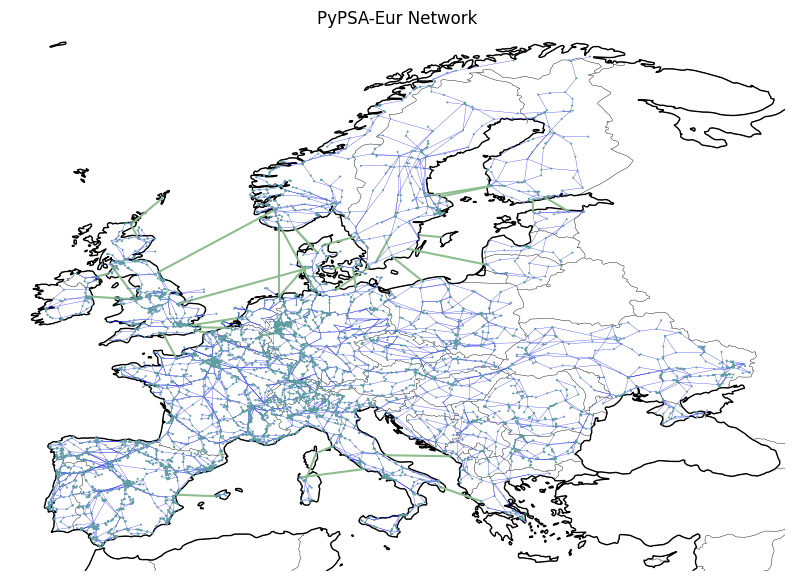

In [48]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Create a figure and a set of axes with a map projection
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Plot the network
n.plot(
    ax=ax,
    bus_sizes=0.005,      # Adjust size of buses
    line_widths=0.2,      # Adjust thickness of lines
    line_colors='blue',   # Adjust color of lines
    title="PyPSA-Eur Network"
)

# Add coastlines for context
ax.coastlines()

# Show the plot
plt.show()

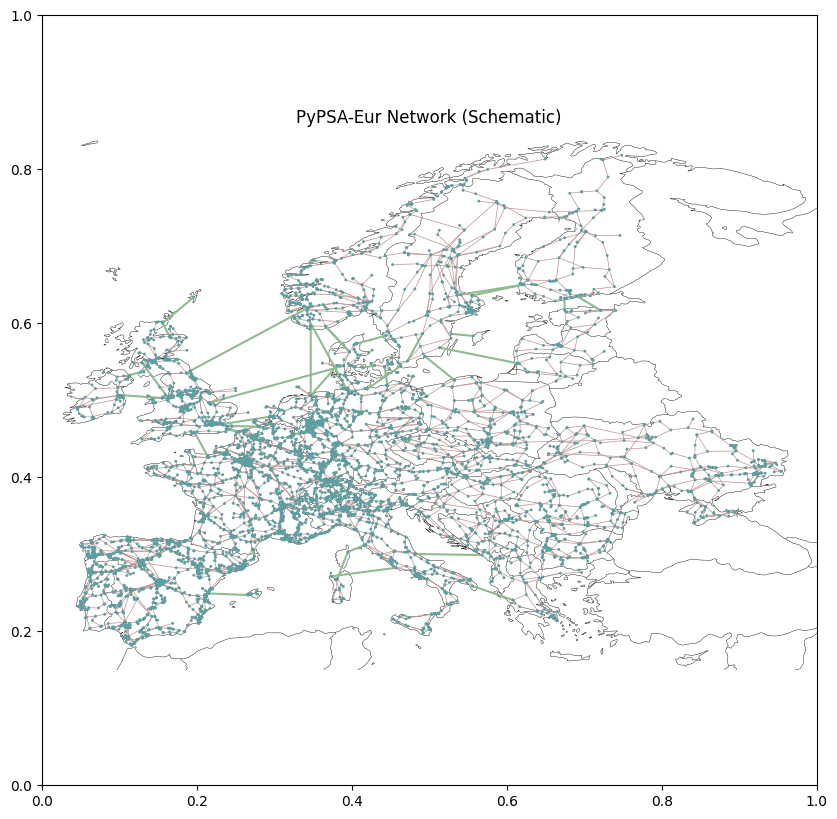

In [49]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(10, 10))

n.plot(
    bus_sizes=0.01,
    line_widths=0.5,
    title="PyPSA-Eur Network (Schematic)"
)

plt.show()

In [50]:
print(n.buses.head())

          voltage dc      symbol under_construction  tags          x  \
bus_id                                                                 
AL1-220       220  f  Substation                  f   AL1  20.111702   
AL10-220      220  f  Substation                  f  AL10  19.522149   
AL2-220       220  f  Substation                  f   AL2  20.031168   
AL3-400       400  f  Substation                  f   AL3  19.652495   
AL4-220       220  f  Substation                  f   AL4  19.972850   

                  y country                                      geometry  
bus_id                                                                     
AL1-220   42.096798      AL  POINT (20.111702399999995 42.09679778825765)  
AL10-220  40.478444      AL  POINT (19.522149214338864 40.47844442711058)  
AL2-220   42.069050      AL  POINT (20.031168199999993 42.06905038823308)  
AL3-400   42.010831      AL  POINT (19.652494799999996 42.01083068818158)  
AL4-220   41.584771      AL          PO

Original network buses: 6737
Portugal sub-network buses: 220


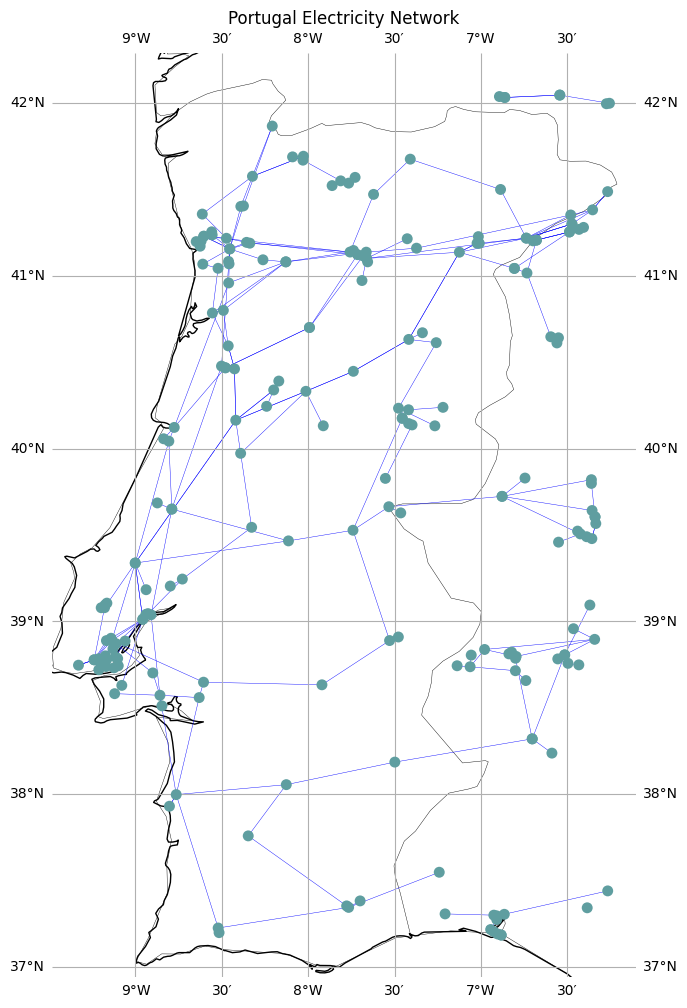

In [51]:
bounds = {
    "x_min": -9.487151,  # min longitude
    "y_min": 37.159107,  # min latitude
    "x_max": -6.252391,  # max longitude
    "y_max": 42.055181,  # max latitude
}


buses_in_portugal = n.buses[
    (n.buses.x >= bounds["x_min"]) & (n.buses.x <= bounds["x_max"]) &
    (n.buses.y >= bounds["y_min"]) & (n.buses.y <= bounds["y_max"])
]


buses_to_keep = buses_in_portugal.index


n_pt = n[buses_to_keep].copy()


print(f"Original network buses: {len(n.buses)}")
print(f"Portugal sub-network buses: {len(n_pt.buses)}")


import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig, ax = plt.subplots(
    figsize=(10, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

padding = 0.5
ax.set_extent([
    bounds["x_min"] - padding,
    bounds["x_max"] + padding,
    bounds["y_min"] - padding,
    bounds["y_max"] + padding
], crs=ccrs.PlateCarree())

n_pt.plot(
    ax=ax,
    bus_sizes=0.001,
    line_widths=0.3,
    line_colors='blue',
    title="Portugal Electricity Network"
)

ax.coastlines()
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

plt.show()

In [52]:
print(f"Portugal sub-network buses: {len(n_pt.buses)}")

Portugal sub-network buses: 220


In [53]:
n_pt.buses

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,voltage,dc,symbol,under_construction,tags,country,geometry
name,,,,,,,,,,,,,,,,,,,,
ES129-220,1.0,,-6.256062,41.999990,AC,,,1.0,0.0,inf,PQ,,,220,f,Substation,f,ES129,ES,POINT (-6.256061600000003 41.999989688171944)
ES182-220,1.0,,-6.406135,41.281457,AC,,,1.0,0.0,inf,PQ,,,220,f,Substation,f,ES182,ES,POINT (-6.4061345999999935 41.281457287524574)
ES183-220,1.0,,-6.432315,41.269867,AC,,,1.0,0.0,inf,PQ,,,220,f,Substation,f,ES183,ES,POINT (-6.432314999999996 41.269866687513954)
ES188-220,1.0,,-6.698736,41.203639,AC,,,1.0,0.0,inf,PQ,,,220,f,Substation,f,ES188,ES,POINT (-6.6987357000000065 41.203639287453306)
ES205-400,1.0,,-6.595627,40.648220,AC,,,1.0,0.0,inf,PQ,,,400,f,Substation,f,ES205,ES,POINT (-6.595627200000005 40.648219986937974)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
way/987944916-400,1.0,,-7.920536,38.633399,AC,,,1.0,0.0,inf,PQ,,,400,f,Substation,f,way/987944916,PT,POINT (-7.920536125564746 38.633398833153095)
way/988035260-400,1.0,,-8.606003,38.648508,AC,,,1.0,0.0,inf,PQ,,,400,f,Substation,f,way/988035260,PT,POINT (-8.606002723434818 38.648508132579146)
way/989699715-400,1.0,,-6.360559,39.799277,AC,,,1.0,0.0,inf,PQ,,,400,f,Substation,f,way/989699715,ES,POINT (-6.360559178196425 39.79927682633197)


In [55]:
# 1. Filter the buses DataFrame for v_nom >= 400
buses_400kv_or_more = n_pt.buses[n_pt.buses['voltage'] >= 400]

# 2. Print the head of the new filtered DataFrame to check
print(f"Found {len(buses_400kv_or_more)} buses with voltage >= 400.")
print("Head of filtered buses (>= 400kV):")
print(buses_400kv_or_more.head())

# 3. new sub-network with *only* these buses

# Get the index (names) of these buses
buses_to_keep_400kv = buses_400kv_or_more.index

# Create the new sub-network
n_pt_400kv = n_pt[buses_to_keep_400kv].copy()

# 4. Plot the new 400kV+ sub-network
print(f"\nCreated new sub-network 'n_pt_400kv' with {len(n_pt_400kv.buses)} buses.")

Found 85 buses with voltage >= 400.
Head of filtered buses (>= 400kV):
           v_nom type         x          y carrier unit location  \
name                                                               
ES205-400    1.0      -6.595627  40.648220      AC                 
ES267-400    1.0      -6.360548  39.820893      AC                 
PT1-400      1.0      -8.090633  41.689726      AC                 
PT13-400     1.0      -7.714568  41.123629      AC                 
PT14-400     1.0      -7.681047  41.117365      AC                 

           v_mag_pu_set  v_mag_pu_min  v_mag_pu_max control generator  \
name                                                                    
ES205-400           1.0           0.0           inf      PQ             
ES267-400           1.0           0.0           inf      PQ             
PT1-400             1.0           0.0           inf      PQ             
PT13-400            1.0           0.0           inf      PQ             
PT14-400      


Created new sub-network 'n_pt_400kv' with 85 buses.


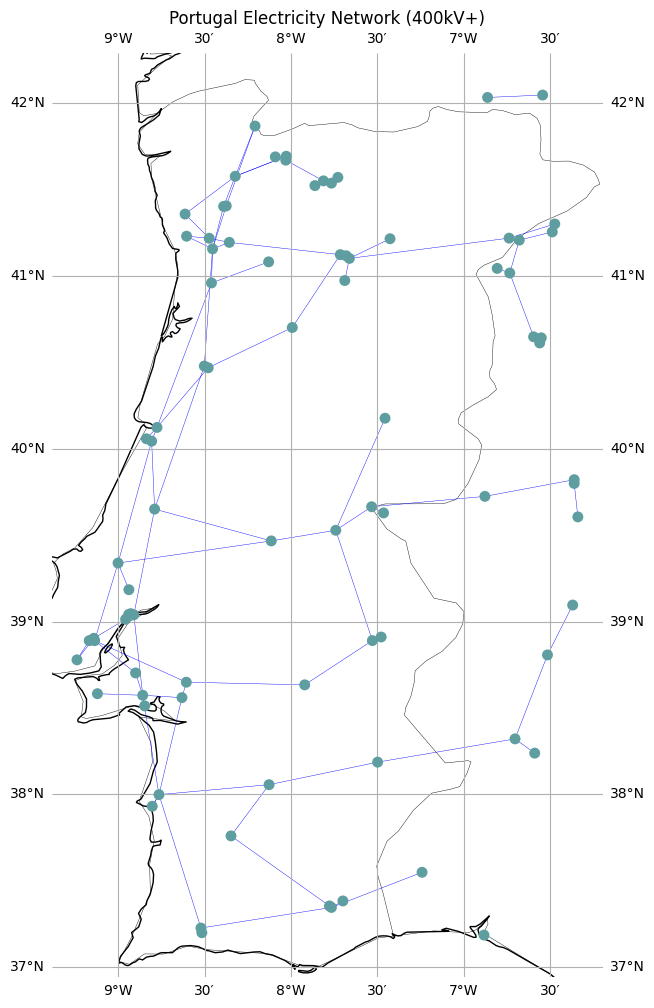

In [56]:

import matplotlib.pyplot as plt
import cartopy.crs as ccrs


fig, ax = plt.subplots(
    figsize=(10, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent([
    bounds["x_min"] - padding,
    bounds["x_max"] + padding,
    bounds["y_min"] - padding,
    bounds["y_max"] + padding
], crs=ccrs.PlateCarree())


n_pt_400kv.plot(
    ax=ax,
    bus_sizes=0.001,
    line_widths=0.3,
    line_colors='blue',
    title="Portugal Electricity Network (400kV+)"
)


ax.coastlines()
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

plt.show()

In [57]:
n_pt_400kv.buses

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,voltage,dc,symbol,under_construction,tags,country,geometry
name,,,,,,,,,,,,,,,,,,,,
ES205-400,1.0,,-6.595627,40.648220,AC,,,1.0,0.0,inf,PQ,,,400,f,Substation,f,ES205,ES,POINT (-6.595627200000005 40.648219986937974)
ES267-400,1.0,,-6.360548,39.820893,AC,,,1.0,0.0,inf,PQ,,,400,f,Substation,f,ES267,ES,POINT (-6.360548353079365 39.82089331982415)
PT1-400,1.0,,-8.090633,41.689726,AC,,,1.0,0.0,inf,PQ,,,400,f,Substation,f,PT1,PT,POINT (-8.090632699999997 41.68972588789486)
PT13-400,1.0,,-7.714568,41.123629,AC,,,1.0,0.0,inf,PQ,,,400,f,Substation,f,PT13,PT,POINT (-7.714567999999989 41.12362858737977)
PT14-400,1.0,,-7.681047,41.117365,AC,,,1.0,0.0,inf,PQ,,,400,f,Substation,f,PT14,PT,POINT (-7.6810471646531555 41.11736492272707)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
way/986410926-400,1.0,,-6.551194,40.642210,AC,,,1.0,0.0,inf,PQ,,,400,f,Substation,f,way/986410926,ES,POINT (-6.551193787012431 40.642209831722674)
way/986410945-400,1.0,,-6.560160,40.612552,AC,,,1.0,0.0,inf,PQ,,,400,f,Substation,f,way/986410945,ES,POINT (-6.560160300536124 40.61255239371956)
way/987944916-400,1.0,,-7.920536,38.633399,AC,,,1.0,0.0,inf,PQ,,,400,f,Substation,f,way/987944916,PT,POINT (-7.920536125564746 38.633398833153095)


In [58]:
#K-means Clustering or Hierarchical Agglomerative Clustering (HAC)

#https://docs.pypsa.org/latest/api/networks/cluster/

import pandas as pd
n_clusters = 10 # Or whatever number you chose

# 2. Create a Series of equal weights (all 1.0)

equal_weights = pd.Series(1.0, index=n_pt_400kv.buses.index)

busmap = n_pt_400kv.cluster.busmap_by_kmeans(
    bus_weightings=equal_weights,
    n_clusters=n_clusters
)

print("Successfully created busmap with equal weightings.")

Successfully created busmap with equal weightings.


Original network had 85 buses.
Clustered network has 10 buses.


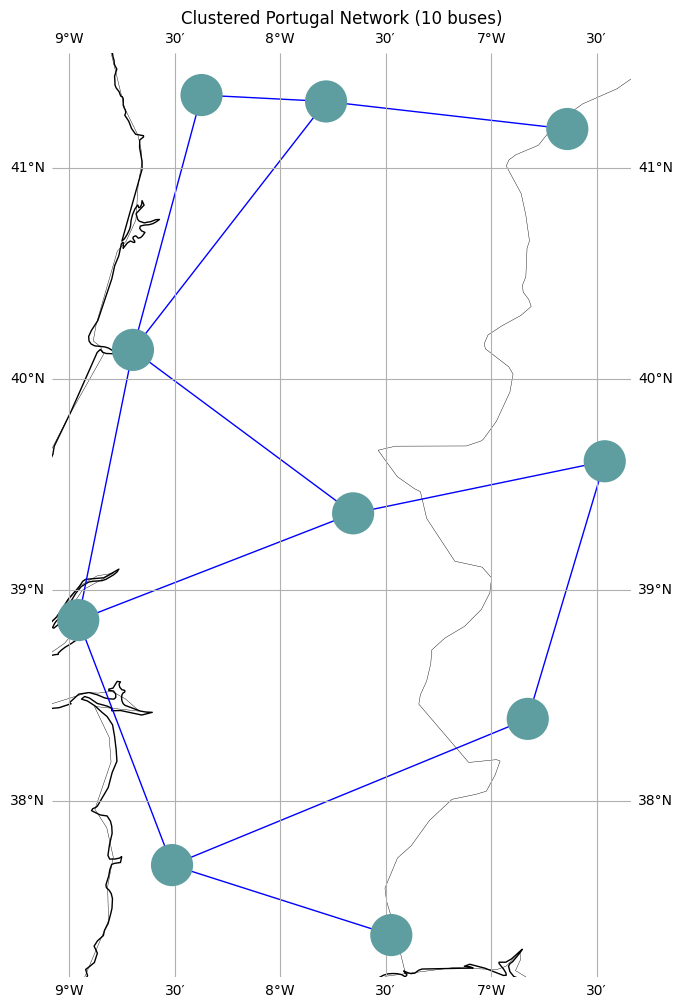

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


n_clusters = 10


equal_weights = pd.Series(1.0, index=n_pt_400kv.buses.index)
busmap = n_pt_400kv.cluster.busmap_by_kmeans(
    bus_weightings=equal_weights,
    n_clusters=n_clusters
)


# Define aggregation strategies for Buses
bus_aggregation_strategies = {
    'tags': 'first',
    'country': 'first',
    'geometry': 'first',
}

# Define aggregation strategies for Lines
line_aggregation_strategies = {
    'circuits': 'sum',
    'tags': 'first',
    'geometry': 'first',
}


cluster = n_pt_400kv.cluster.get_clustering_from_busmap(
    busmap,
    bus_strategies=bus_aggregation_strategies,
    line_strategies=line_aggregation_strategies
)
n_clustered = cluster.n

print(f"Original network had {len(n_pt_400kv.buses)} buses.")
print(f"Clustered network has {len(n_clustered.buses)} buses.")

fig, ax = plt.subplots(
    figsize=(10, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent([
    bounds["x_min"] - padding,
    bounds["x_max"] + padding,
    bounds["y_min"] - padding,
    bounds["y_max"] + padding
], crs=ccrs.PlateCarree())

n_clustered.plot(
    ax=ax,
    bus_sizes=0.01,
    line_widths=1.0,
    line_colors='blue',
    title=f"Clustered Portugal Network ({n_clusters} buses)"
)

ax.coastlines()
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

plt.show()